In [12]:
%pip install imbalanced-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('features.csv')

drop_cols = ['order_id', 'order_date', 'customer_id']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['is_returned'])
y = df_encoded['is_returned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (80, 114)
X_test: (20, 114)


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

baseline_rf = RandomForestClassifier(random_state=42)
baseline_rf.fit(X_train, y_train)

y_pred_before = baseline_rf.predict(X_test)
f1_before = f1_score(y_test, y_pred_before)
print(f"Pre-SMOTE F1 Score: {f1_before:.4f}")

Pre-SMOTE F1 Score: 0.0000


In [4]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=4)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {0: 75, 1: 5}
After SMOTE: {0: 75, 1: 75}


In [5]:
from sklearn.ensemble import RandomForestClassifier

production_rf_model = RandomForestClassifier(random_state=42)
production_rf_model.fit(X_train_balanced, y_train_balanced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [7]:
from sklearn.metrics import classification_report, f1_score

y_pred_after = production_rf_model.predict(X_test)

print("=== POST-SMOTE Classification Report ===")
print(classification_report(y_test, y_pred_after))

f1_after = f1_score(y_test, y_pred_after)
print(f"Post-SMOTE F1 Score: {f1_after:.4f}")

print(f"\nComparison: {f1_before:.4f} (before) → {f1_after:.4f} (after)")

=== POST-SMOTE Classification Report ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.00      0.00      0.00         1

    accuracy                           0.95        20
   macro avg       0.47      0.50      0.49        20
weighted avg       0.90      0.95      0.93        20

Post-SMOTE F1 Score: 0.0000

Comparison: 0.0000 (before) → 0.0000 (after)


c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DIGITAL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

C:\Users\DIGITAL\AppData\Local\Temp\ipykernel_11884\2057722130.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')


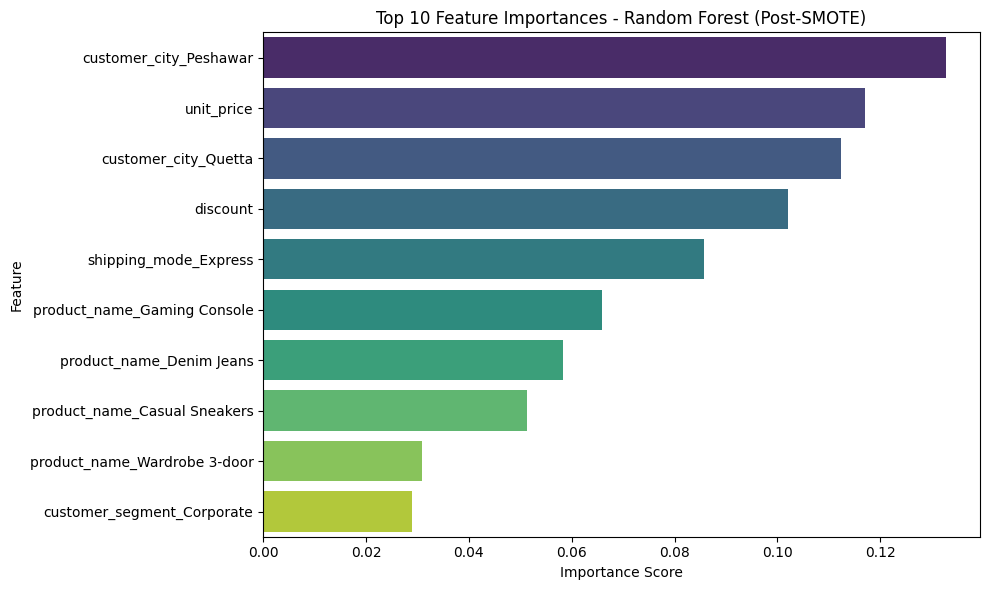

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

importances = production_rf_model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')
plt.title('Top 10 Feature Importances - Random Forest (Post-SMOTE)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

## Model Interpretability — Business Translation

Based on the Feature Importance chart, our Random Forest model relies most heavily on the following factors to predict product returns:

1. **Customer City (Peshawar)**  the single most influential factor in the model's predictions
2. **Unit Price**  the second most important driver
3. **Customer City (Quetta)**  also a strong contributor, along with **Discount** and **Shipping Mode (Express)**

**In business terms:** The model predicts whether an order will be returned mainly based on where the customer is located (Peshawar and Quetta show higher return tendencies) and how expensive the item is. Orders with higher unit prices, larger discounts, and Express shipping also show a stronger link to returns. This suggests the company could reduce returns by paying closer attention to high-value orders and reviewing return patterns in specific cities like Peshawar and Quetta.

In [9]:
import joblib

joblib.dump(production_rf_model, 'production_rf_model.pkl')
print("Model saved")

Model saved
